<a href="https://colab.research.google.com/github/Kenduiwo/kenduiwo/blob/main/kiva_loan_in_Nigeria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
sns.set(color_codes=True)

In [49]:
kiva_loans=pd.read_csv("/content/drive/MyDrive/kiva_loans.csv")
kiva_loans_themes=pd.read_csv("/content/drive/MyDrive/loan_theme_ids.csv")
kiva_loans_region=pd.read_csv("/content/drive/MyDrive/loan_themes_by_region.csv")

#What country got the most loans? Does the number of times a country is referenced relate to the quantity of loans it got?

In [50]:
country_loan_count = kiva_loans['country'].value_counts().reset_index().head(10)
country_loan_count.columns = ['country','loan count']
country_loan_count

,country,loan count
0,Philippines,160441
1,Kenya,75825
2,El Salvador,39875
3,Cambodia,34836
4,Pakistan,26857
5,Peru,22233
6,Colombia,21995
7,Uganda,20601
8,Tajikistan,19580
9,Ecuador,13521


#The above countries got the most number of loans with Philippines in the lead followed by Kenya.

In [51]:
country_loan_amount = kiva_loans.groupby('country')['loan_amount'].sum().sort_values(ascending = False).head(10).reset_index()
country_loan_amount

,country,loan_amount
0,Philippines,55342225.0
1,Kenya,34534300.0
2,United States,31496375.0
3,Peru,30867400.0
4,Paraguay,29629075.0
5,El Salvador,26603650.0
6,Cambodia,19872700.0
7,Bolivia,19843250.0
8,Rwanda,16646300.0
9,Uganda,15389350.0


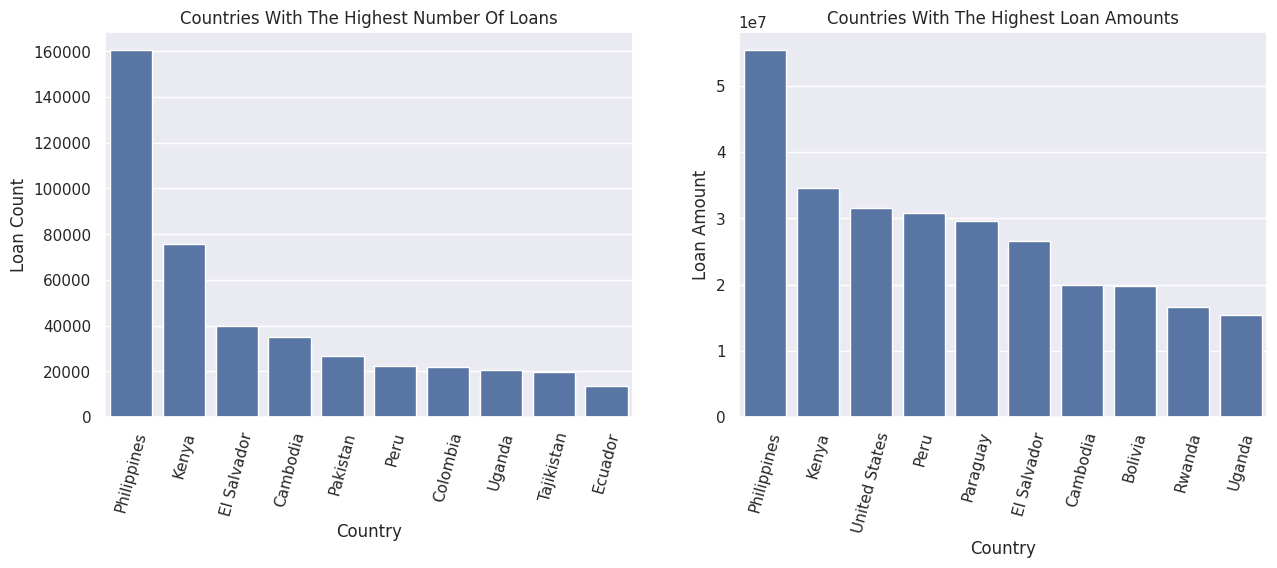

In [52]:
plt.figure(figsize = [15,5])
plt.subplot(1,2,1)
sns.barplot(x = 'country',y = 'loan count',data = country_loan_count)
plt.title("Countries With The Highest Number Of Loans")
plt.xlabel('Country')
plt.ylabel('Loan Count')
plt.xticks(rotation = 75)

plt.subplot(1,2,2)
sns.barplot(x = 'country',y = 'loan_amount',data = country_loan_amount)
plt.title("Countries With The Highest Loan Amounts")
plt.xlabel('Country')
plt.ylabel('Loan Amount')
plt.xticks(rotation = 75)
plt.show()

#For the two leading countries, the number of times they got loans is proportional to the loan amounts. This is not the case for the other countries. In both scenarios however, Phillipine is leading by far. For the remaining nine countries, the loan amounts have lesser ranges.

#Subsetting the data set to country of choice which is Nigeria.

In [53]:
nigeria = kiva_loans[kiva_loans['country']=='Nigeria'].reset_index(drop = True)

In [54]:
nigeria_2=kiva_loans_region[kiva_loans_region['country']=='Nigeria'].reset_index(drop = True)
nigeria_2.head(2)

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,288,Babban Gona Farmers Organization,Agriculture,a1050000000v6AI,Agriculture,Nigeria,No,Kaduna,NaN,NGA,...,898300,"Kaduna, Nigeria","[(10.5104642, 7.4165053)]",Kaduna; Kaduna; Nigeria,"(10.5104642, 7.4165053)",10.510464,7.416505,"Kaduna, Nigeria","(10.5104642, 7.4165053)",100.0
1,288,Babban Gona Farmers Organization,Agriculture,a1050000004GHPs,Bridge/Income Smoothing,Nigeria,No,Kaduna,NaN,NGA,...,650125,"Kaduna, Nigeria","[(10.5104642, 7.4165053)]",Kaduna; Kaduna; Nigeria,"(10.5104642, 7.4165053)",10.510464,7.416505,"Kaduna, Nigeria","(10.5104642, 7.4165053)",100.0


##Reviewing the data set to understand it.

In [55]:
nigeria.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,689794,1450.0,1450.0,Agriculture,Agriculture,to help Uche purchase a modern palm oil proces...,NG,Nigeria,Amichi,NGN,365.0,2014-03-27 08:59:23+00:00,2014-06-24 07:00:00+00:00,2014-04-04 15:49:54+00:00,11.0,50,"#Biz Durable Asset, #Supporting Family, #Job C...",female,bullet,2014-03-27
1,689739,850.0,850.0,Agriculture,Agriculture,"A loan of 140,000 Naira will help Chinyere pur...",NG,Nigeria,Nnewi,NGN,365.0,2014-03-27 08:10:09+00:00,2014-06-24 07:00:00+00:00,2014-04-04 12:48:18+00:00,6.0,30,NaN,female,bullet,2014-03-27


##Above is a glimpse of the data set

In [56]:
nigeria['funded_amount']==nigeria['loan_amount']

,0
0,True
1,True
2,True
3,True
4,True
...,...
10131,False
10132,False
10133,False
10134,False


##The loan amount is not equal to the funded amount in all instances.

In [57]:
nigeria['activity']==nigeria['sector']

,0
0,True
1,True
2,True
3,True
4,True
...,...
10131,False
10132,False
10133,False
10134,False


##Activity does not match the sector in all instances.

In [58]:
nigeria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10136 entries, 0 to 10135
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  10136 non-null  int64  
 1   funded_amount       10136 non-null  float64
 2   loan_amount         10136 non-null  float64
 3   activity            10136 non-null  object 
 4   sector              10136 non-null  object 
 5   use                 10130 non-null  object 
 6   country_code        10136 non-null  object 
 7   country             10136 non-null  object 
 8   region              10130 non-null  object 
 9   currency            10136 non-null  object 
 10  partner_id          10136 non-null  float64
 11  posted_time         10136 non-null  object 
 12  disbursed_time      10136 non-null  object 
 13  funded_time         9137 non-null   object 
 14  term_in_months      10136 non-null  float64
 15  lender_count        10136 non-null  int64  
 16  tags

##The data set has 10136 entries

##Checking for missing values

In [59]:
nigeria.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,6
country_code,0
country,0
region,6
currency,0


##Some string values are missing. These are in columns that do not hold key values which is a bit of relief to this analysis. We can indicate not applicable on the missing values.

In [60]:
nigeria.fillna('n_a',inplace = True)

In [61]:
nigeria.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,1.013600e+04,10136.000000,10136.000000,10136.000000,10136.000000,10136.000000
mean,1.000622e+06,187.976026,217.595699,289.007103,16.605564,6.196823
std,1.798822e+05,395.944407,406.236600,8.882800,2.861187,13.084765
min,6.897390e+05,0.000000,25.000000,288.000000,2.000000,0.000000
25%,8.149605e+05,75.000000,100.000000,288.000000,14.000000,3.000000
50%,9.815590e+05,125.000000,150.000000,288.000000,17.000000,5.000000
75%,1.133254e+06,225.000000,250.000000,288.000000,19.000000,7.000000
max,1.336342e+06,35000.000000,35000.000000,486.000000,22.000000,1150.000000


##The maximum loan given was 35000 and the maximum term was 22 months. The minimum loan amount was 25 and minimum term 2 months.

In [62]:
nigeria.duplicated().sum()

0

##There are no duplicated values in the data set.

In [63]:
nigeria.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

#Which region had the highest loan amounts?

In [64]:
nigeria['region'].unique()

array(['Amichi', 'Nnewi', 'Elele', 'Umutanzi', 'Kaduna', 'n_a',
       'Okwu-Ubaha Okporo', 'Uruagu', 'Ubaha Okporo', 'Obiofia',
       'Nnewichi', 'Ozubulu', 'Umudim', 'Abobur', 'Akatta Oru East',
       'Ojoto', 'Akaboezem', 'Otolo Nnewi', 'Nnobi', 'Enugu-ukwe',
       'ORAIFITE', 'OBA'], dtype=object)

In [65]:
nigeria['region'].nunique()

22

##There were 22 regions in total

In [66]:
# which region got the most loans
loan_count_region = nigeria['region'].value_counts().reset_index().head(10)
loan_count_region.columns=['region','frequency']
loan_count_region

,region,frequency
0,Kaduna,10000
1,Uruagu,28
2,Nnewi,13
3,Nnewichi,10
4,Ozubulu,9
5,Okwu-Ubaha Okporo,9
6,Nnobi,9
7,Obiofia,8
8,Akaboezem,7
9,Umutanzi,7


##Kaduna region got loans 10000 times followed by Uruagu and NNewi as shown above. Let's look at the total loan amount per region.

In [67]:
nigeria_loan_region = nigeria.groupby('region')[['loan_amount']].sum().sort_values(by = 'loan_amount',ascending = False).head(10).reset_index()
nigeria_loan_region.columns=['region','loan_amount']
nigeria_loan_region

,region,loan_amount
0,Kaduna,2048900.0
1,Uruagu,31650.0
2,Nnewi,18600.0
3,Obiofia,11125.0
4,Okwu-Ubaha Okporo,10950.0
5,Ozubulu,10825.0
6,Umutanzi,10650.0
7,Nnewichi,10150.0
8,Akaboezem,8700.0
9,Nnobi,8175.0


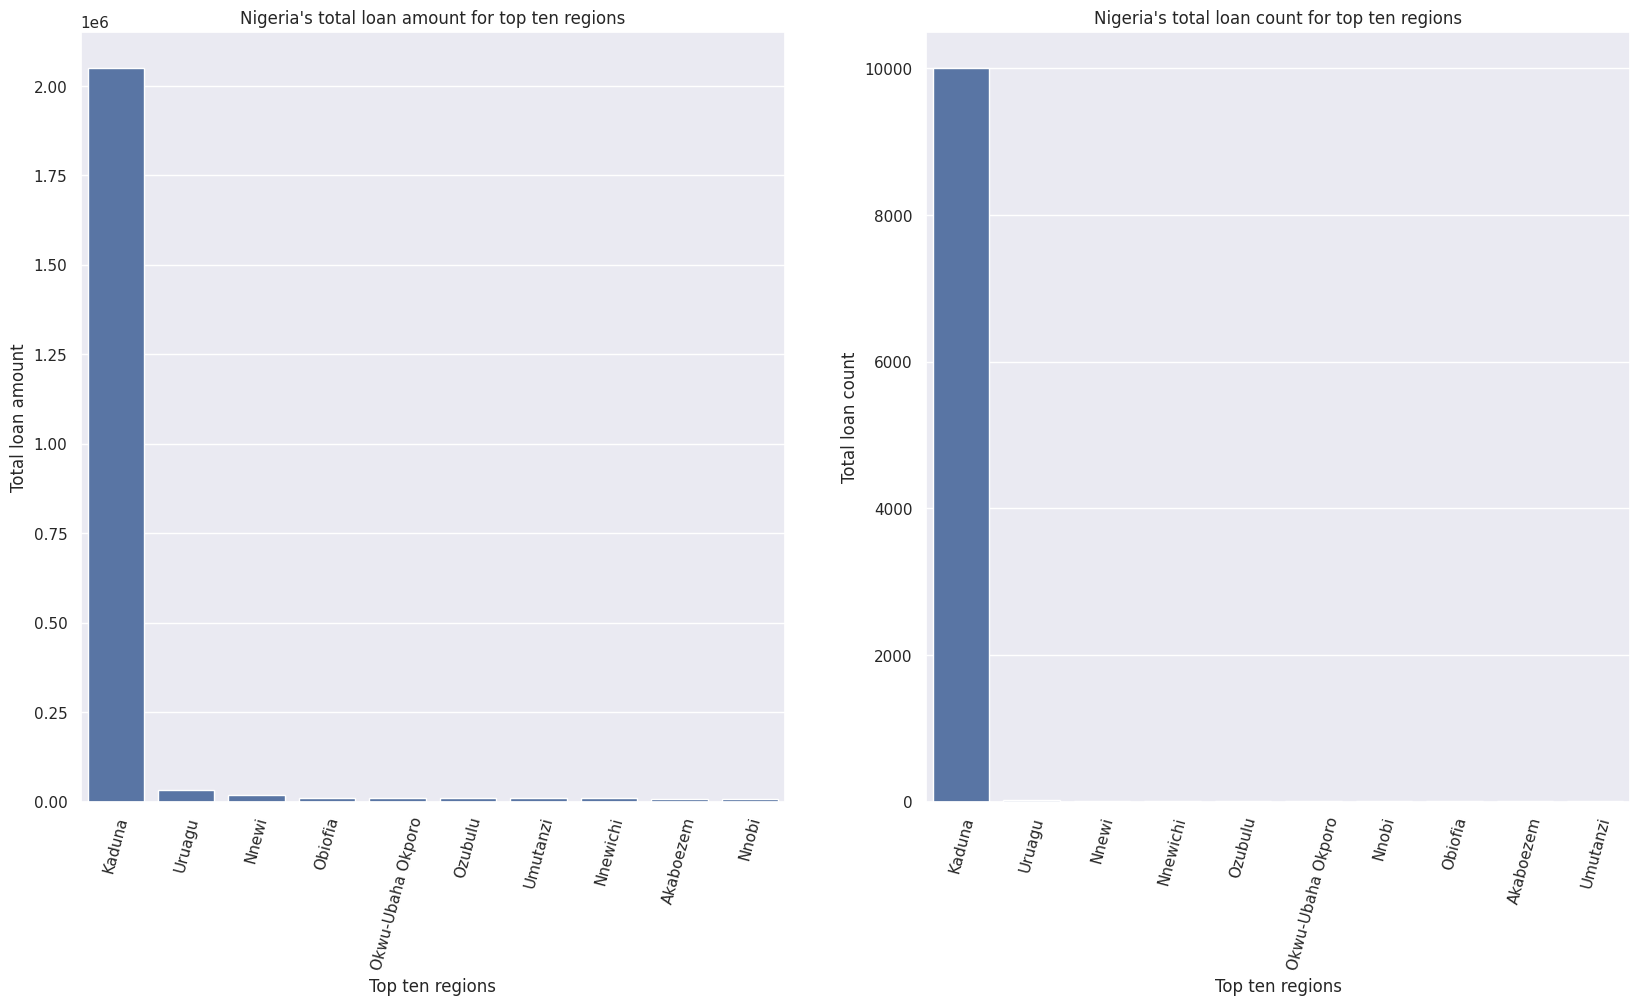

In [68]:
plt.figure(figsize = (20,10))

plt.subplot(1,2,1)
sns.barplot(x=nigeria_loan_region['region'],y=nigeria_loan_region['loan_amount'])
plt.title("Nigeria's total loan amount for top ten regions")
plt.ylabel('Total loan amount')
plt.xlabel('Top ten regions')
plt.xticks(rotation = 75)

plt.subplot(1,2,2)
sns.barplot(x=loan_count_region['region'],y=loan_count_region['frequency'])
plt.title("Nigeria's total loan count for top ten regions")
plt.ylabel('Total loan count')
plt.xlabel('Top ten regions')
plt.xticks(rotation = 75)




plt.show()

##Above are the top ten regions in loan amounts. For the top three regions, the number of times the regions got loans is proportional to the loan amount. This does not apply to the other regions.

#What sector got the most loans? Does the number of times a sector is referenced relate to the quantity of loans it got?

In [69]:
nigeria['sector'].unique()

array(['Agriculture', 'Education', 'Personal Use', 'Food', 'Retail',
       'Services', 'Construction'], dtype=object)

#7 sectors acquired loans in Nigeria. The number of times the sectors got the loans is as below:

In [70]:
#sector with the most loans
nigeria['sector'].value_counts()

,count
sector,
Agriculture,5996
Personal Use,2983
Education,1064
Food,85
Retail,4
Services,3
Construction,1


##Let's look at the total loan amount for each sector and compare with the number of times the sectors acquired loans

In [71]:
nigeria_sector_loans = nigeria.groupby('sector')[['loan_amount']].sum().sort_values(by = 'loan_amount',ascending=False).reset_index()
nigeria_sector_loans.columns = ['sector','loan_amount_total']
nigeria_sector_loans

,sector,loan_amount_total
0,Agriculture,1185600.0
1,Personal Use,572125.0
2,Education,315925.0
3,Food,93125.0
4,Retail,35450.0
5,Services,1875.0
6,Construction,1450.0


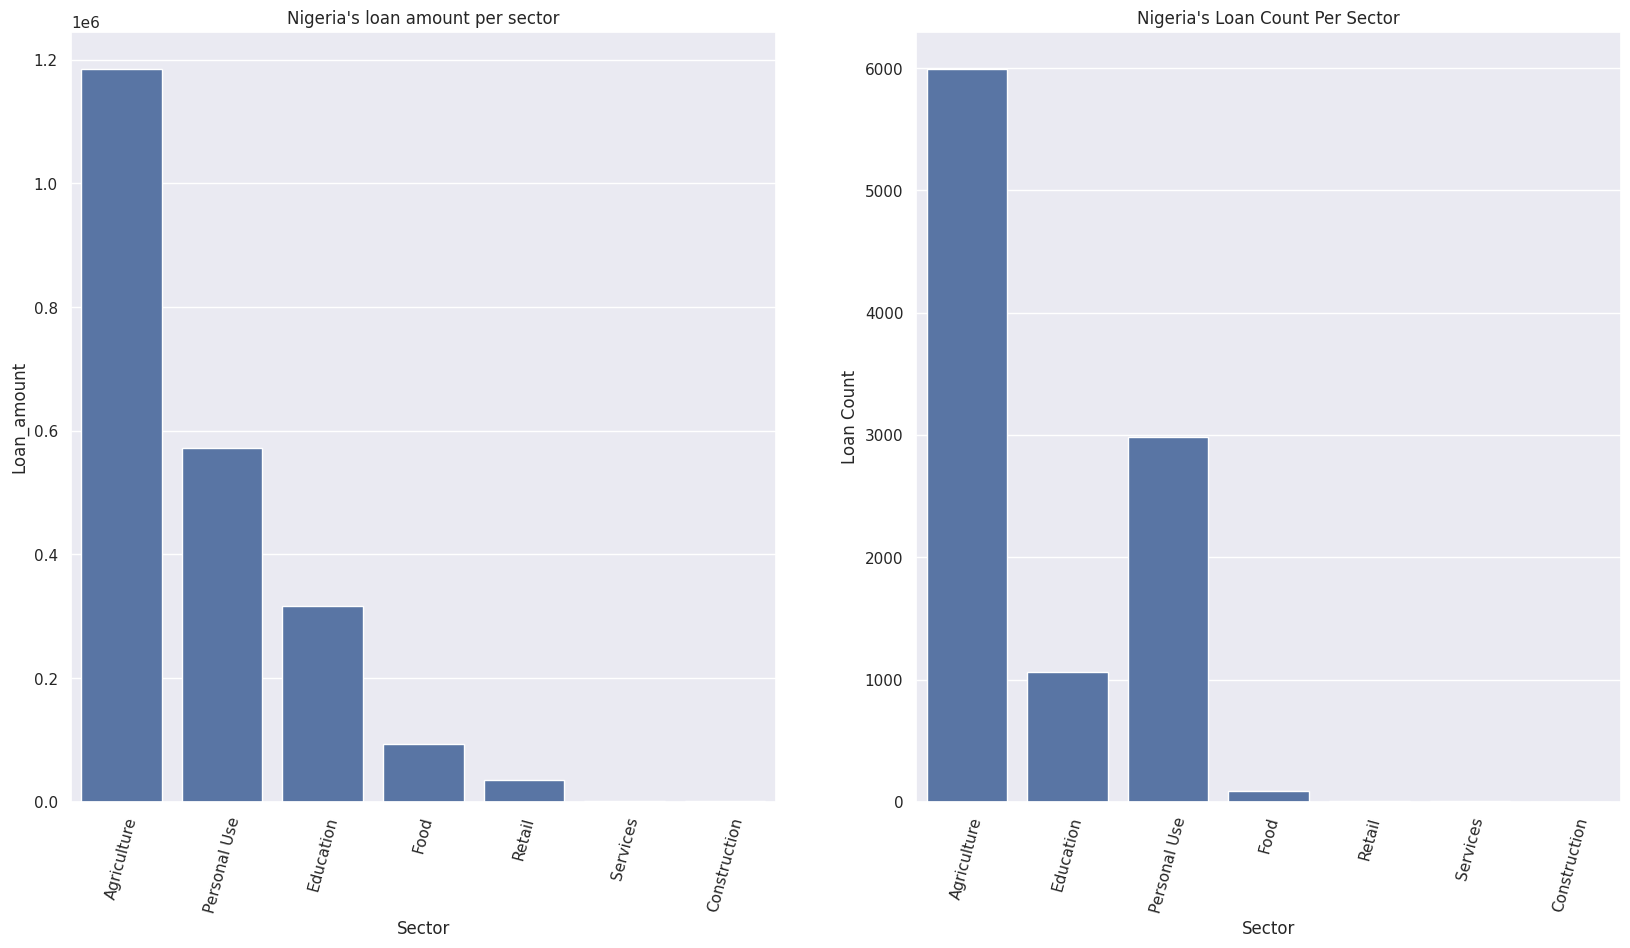

In [72]:
plt.figure(figsize = (20,10))
plt.subplot(1,2,1)
sns.barplot(x=nigeria_sector_loans['sector'],y=nigeria_sector_loans['loan_amount_total'])
plt.title("Nigeria's loan amount per sector")
plt.xlabel('Sector')
plt.ylabel('Loan_amount')
plt.xticks(rotation = 75)

plt.subplot(1,2,2)
sns.countplot(x = nigeria['sector'])
plt.title("Nigeria's Loan Count Per Sector")
plt.xlabel('Sector')
plt.ylabel('Loan Count')
plt.xticks(rotation = 75)
plt.show()


##The agricultural sector is leading in both loan amount and loan count. Education and Personal use sectors are popular as well. For the top three sectors, the loan amount is evidently proportional to the frequency of loans.

#For the top sector, what activity had the highest amount of loans? What does that say about that activity?

In [73]:
nigeria['activity'].unique()

array(['Agriculture', 'Farming', 'Farm Supplies',
       'Primary/secondary school costs', 'Personal Expenses',
       'Consumer Goods', 'Food', 'Higher education costs', 'Retail',
       'Food Production/Sales', 'Services', 'Renewable Energy Products',
       'Well digging'], dtype=object)

In [74]:
nigeria.groupby('sector')['activity'].value_counts()

sector        activity                      
Agriculture   Farming                           5889
              Agriculture                         75
              Farm Supplies                       32
Construction  Well digging                         1
Education     Primary/secondary school costs    1063
              Higher education costs               1
Food          Food Production/Sales               83
              Food                                 2
Personal Use  Personal Expenses                 2962
              Consumer Goods                      21
Retail        Retail                               3
              Renewable Energy Products            1
Services      Services                             3
Name: count, dtype: int64

##For the top sector (Agriculture), farming activity had the most number of loans followed by personal expenses in the personal use sector. In conclusion, farming is a popular activity in nigeria that requires frequent funding. Let's look at the total loan amount for each activity and compare with the frequency of loans for the same.

In [75]:
nigeria_loan_activity = nigeria.groupby('activity')[['loan_amount']].sum().sort_values(by = 'loan_amount',ascending= False).reset_index().head(10)
nigeria_loan_activity

,activity,loan_amount
0,Farming,1113075.0
1,Personal Expenses,568050.0
2,Primary/secondary school costs,315875.0
3,Food Production/Sales,92975.0
4,Agriculture,65625.0
5,Renewable Energy Products,35000.0
6,Farm Supplies,6900.0
7,Consumer Goods,4075.0
8,Services,1875.0
9,Well digging,1450.0


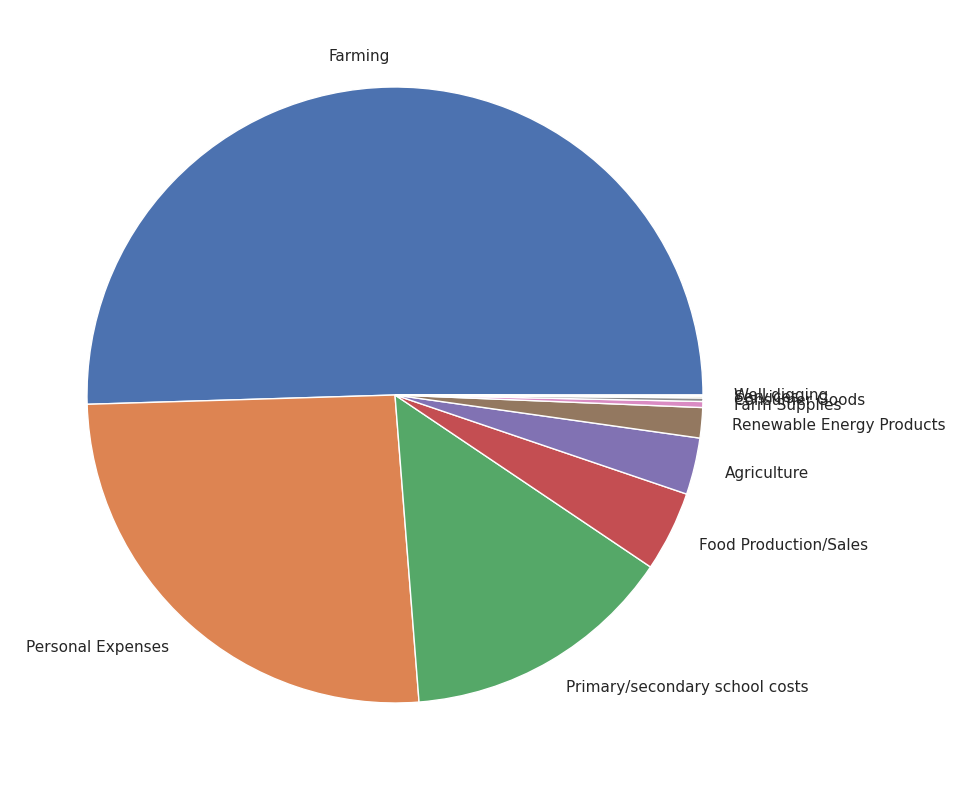

In [76]:
plt.figure(figsize = (10,10))
plt.pie(nigeria_loan_activity['loan_amount'],labels = nigeria_loan_activity['activity'])

plt.show()

##Farming accounts for 50% of the total loan amount in Nigeria. We can conclude that farming is a major economic activity in Nigeria and requires alot of funding. For the top five activities, the loan amount is proportional to the number of times which is not applicable with the rest of the activities.

#The top ten loan activities were as follows:

In [77]:
top_activity = nigeria[['activity']].value_counts().reset_index().head(10)
top_activity.columns=['activity','frequency']
top_activity

,activity,frequency
0,Farming,5889
1,Personal Expenses,2962
2,Primary/secondary school costs,1063
3,Food Production/Sales,83
4,Agriculture,75
5,Farm Supplies,32
6,Consumer Goods,21
7,Retail,3
8,Services,3
9,Food,2


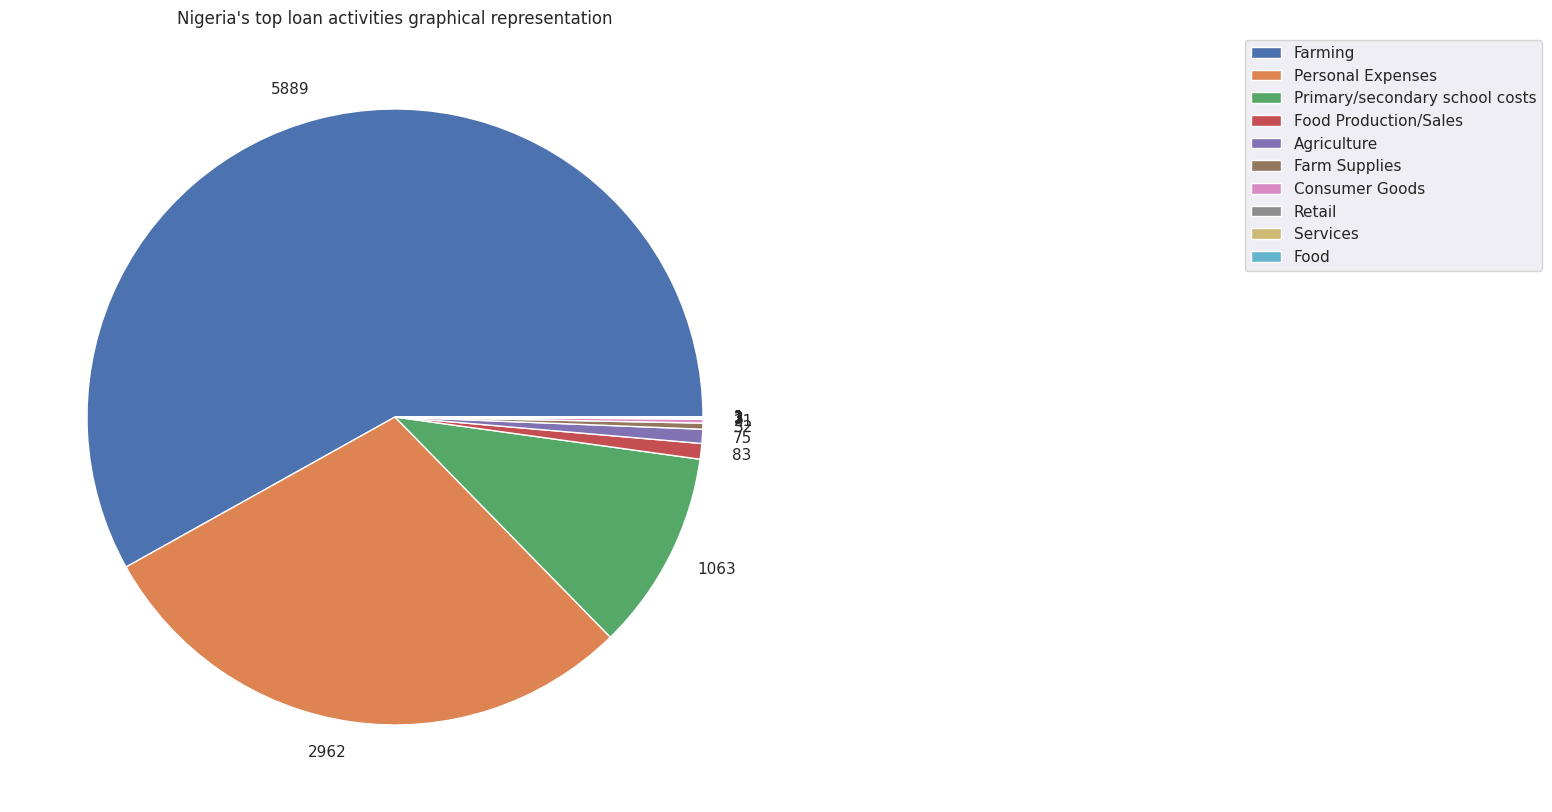

In [78]:
plt.figure(figsize = (15,10))
plt.pie(nigeria['activity'].value_counts(),labels = nigeria['activity'].value_counts())
plt.legend(top_activity['activity'],loc= 'upper right',bbox_to_anchor = (2,1))
plt.title("Nigeria's top loan activities graphical representation")

plt.show()

##Other than having the largest loan amount, farming also has the most borrowers. Farming seems to be a popular activity in Nigeria. Could be Nigeria is self dependent in food production and does not import alot or maybe high unemployment rates in the formal sector leading people to self employ in farming.

#What were the numbers between male and female recipients? Does that communicate anything?

In [79]:
def gender_lead(gender):
    gender=str(gender)
    if gender.startswith ('f'):
        gender='female'
    else:
        gender = 'male'
    return gender


In [80]:
nigeria['main_gender']=nigeria['borrower_genders'].apply(gender_lead)

##I created a new column named main_gender on the assumption that the first gender that appears under borrow_genders represents the majority.

In [81]:
nigeria.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date,main_gender
0,689794,1450.0,1450.0,Agriculture,Agriculture,to help Uche purchase a modern palm oil proces...,NG,Nigeria,Amichi,NGN,...,2014-03-27 08:59:23+00:00,2014-06-24 07:00:00+00:00,2014-04-04 15:49:54+00:00,11.0,50,"#Biz Durable Asset, #Supporting Family, #Job C...",female,bullet,2014-03-27,female
1,689739,850.0,850.0,Agriculture,Agriculture,"A loan of 140,000 Naira will help Chinyere pur...",NG,Nigeria,Nnewi,NGN,...,2014-03-27 08:10:09+00:00,2014-06-24 07:00:00+00:00,2014-04-04 12:48:18+00:00,6.0,30,n_a,female,bullet,2014-03-27,female


In [82]:
nigeria.value_counts('main_gender')

,count
main_gender,
male,8859
female,1277


In [83]:
nigeria.groupby('sector')['main_gender'].value_counts()

sector        main_gender
Agriculture   male           5294
              female          702
Construction  female            1
Education     male            932
              female          132
Food          female           68
              male             17
Personal Use  male           2616
              female          367
Retail        female            4
Services      female            3
Name: count, dtype: int64

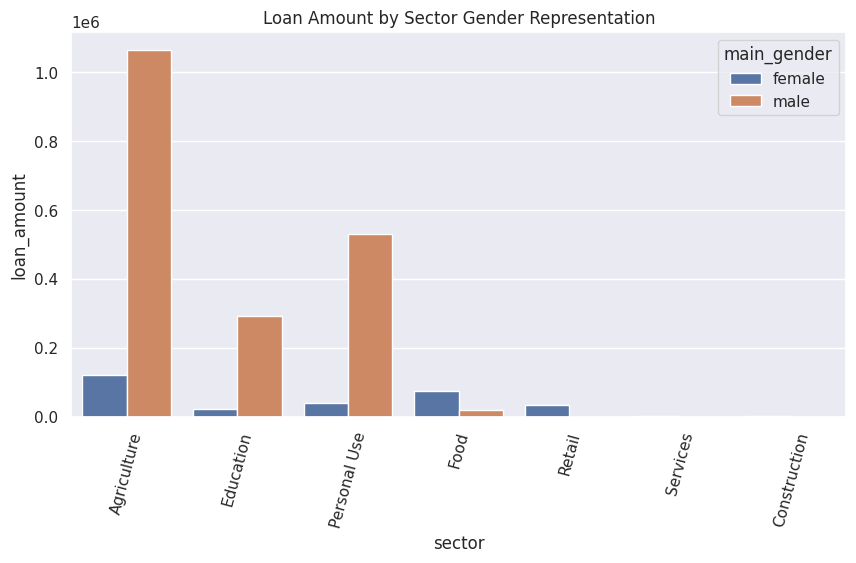

In [84]:
plt.figure(figsize = (10,5))

plt.title('Loan Amount by Sector Gender Representation')

plt.xticks(rotation = 75)

sns.barplot(x = 'sector', y = 'loan_amount', data = nigeria, ci = None,
           estimator = np.sum, hue = 'main_gender')

plt.show()

##There were more male borrowers compared to the female ones. The above information breaks down the total gender count for each of the sectors. The male gender seems to be very aggressive in borrowing in Nigeria especially in the personal use, education and agricultural sectors.

#What does the loan amount look like for various repayment interval? In various sectors? In various activities?

In [85]:
nigeria['repayment_interval'].unique()

array(['bullet', 'irregular'], dtype=object)

In [86]:
nigeria.groupby('sector')['repayment_interval'].value_counts()

sector        repayment_interval
Agriculture   bullet                5996
Construction  bullet                   1
Education     bullet                1064
Food          bullet                  85
Personal Use  bullet                2983
Retail        bullet                   3
              irregular                1
Services      bullet                   3
Name: count, dtype: int64

In [87]:
nigeria_repayment_interval = nigeria[['sector','activity','region','loan_amount','repayment_interval']]
nigeria_repayment_interval

,sector,activity,region,loan_amount,repayment_interval
0,Agriculture,Agriculture,Amichi,1450.0,bullet
1,Agriculture,Agriculture,Nnewi,850.0,bullet
2,Agriculture,Agriculture,Elele,1475.0,bullet
3,Agriculture,Agriculture,Umutanzi,1000.0,bullet
4,Agriculture,Agriculture,Umutanzi,1125.0,bullet
...,...,...,...,...,...
10131,Agriculture,Farming,Kaduna,300.0,bullet
10132,Agriculture,Farming,Kaduna,200.0,bullet
10133,Agriculture,Farming,Kaduna,375.0,bullet
10134,Food,Food Production/Sales,Nnobi,1225.0,bullet


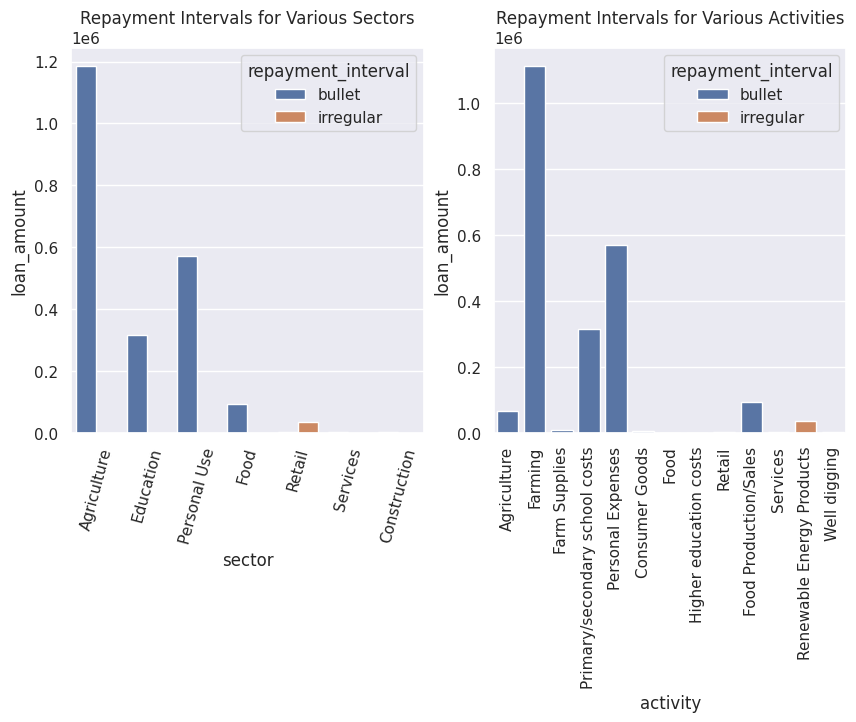

In [88]:
plt.figure(figsize = (10,5))


plt.subplot(1,2,1)

plt.title("Repayment Intervals for Various Sectors")
sns.barplot(x = 'sector', y = 'loan_amount', data = nigeria_repayment_interval, ci = None,
           estimator = np.sum, hue = 'repayment_interval')
plt.xticks(rotation = 75)

plt.subplot(1,2,2)

plt.title("Repayment Intervals for Various Activities")
sns.barplot(x = 'activity', y = 'loan_amount', data = nigeria_repayment_interval, ci = None,
           estimator = np.sum, hue = 'repayment_interval')
plt.xticks(rotation = 90)
plt.show()

#The most dominant field partners.¶

In [89]:
nigeria['partner_id'].value_counts()

,count
partner_id,
288.0,10005
365.0,130
486.0,1


In [90]:
nigeria['partners']=nigeria_2['Field Partner Name']
nigeria.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date,main_gender,partners
0,689794,1450.0,1450.0,Agriculture,Agriculture,to help Uche purchase a modern palm oil proces...,NG,Nigeria,Amichi,NGN,...,2014-06-24 07:00:00+00:00,2014-04-04 15:49:54+00:00,11.0,50,"#Biz Durable Asset, #Supporting Family, #Job C...",female,bullet,2014-03-27,female,Babban Gona Farmers Organization
1,689739,850.0,850.0,Agriculture,Agriculture,"A loan of 140,000 Naira will help Chinyere pur...",NG,Nigeria,Nnewi,NGN,...,2014-06-24 07:00:00+00:00,2014-04-04 12:48:18+00:00,6.0,30,n_a,female,bullet,2014-03-27,female,Babban Gona Farmers Organization


In [91]:
nigeria['partners'].value_counts()

,count
partners,
Nke-Anyi Farmers Multipurpose Cooperative Society,17
Babban Gona Farmers Organization,2
"N/A, direct to Sosai Renewable Energy",1


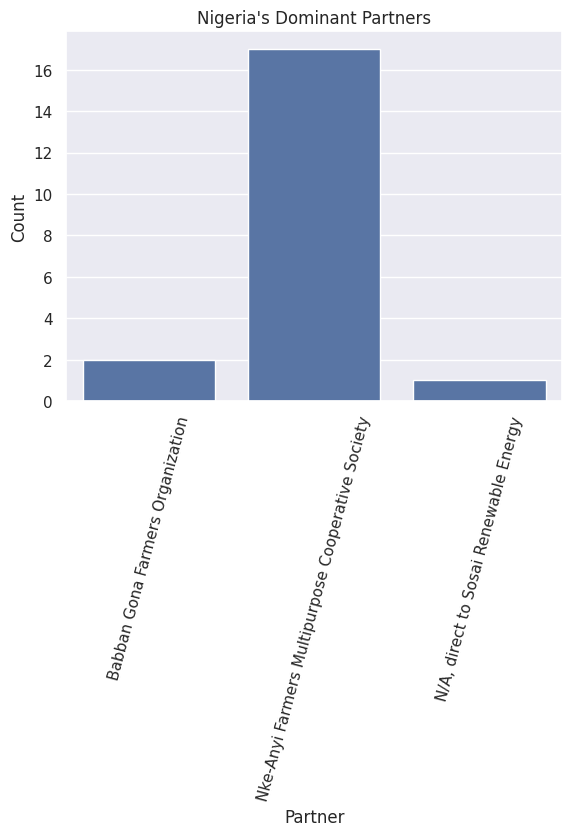

In [92]:
sns.countplot(x = nigeria['partners'])
plt.title("Nigeria's Dominant Partners")
plt.xlabel('Partner')
plt.ylabel('Count')
plt.xticks(rotation = 75)
plt.show()

#The partner names and their total loan amount.

In [94]:
nigeria_partners = nigeria.groupby('partners')['loan_amount'].sum().reset_index()
nigeria_partners

,partners,loan_amount
0,Babban Gona Farmers Organization,2300.0
1,"N/A, direct to Sosai Renewable Energy",50.0
2,Nke-Anyi Farmers Multipurpose Cooperative Society,9925.0


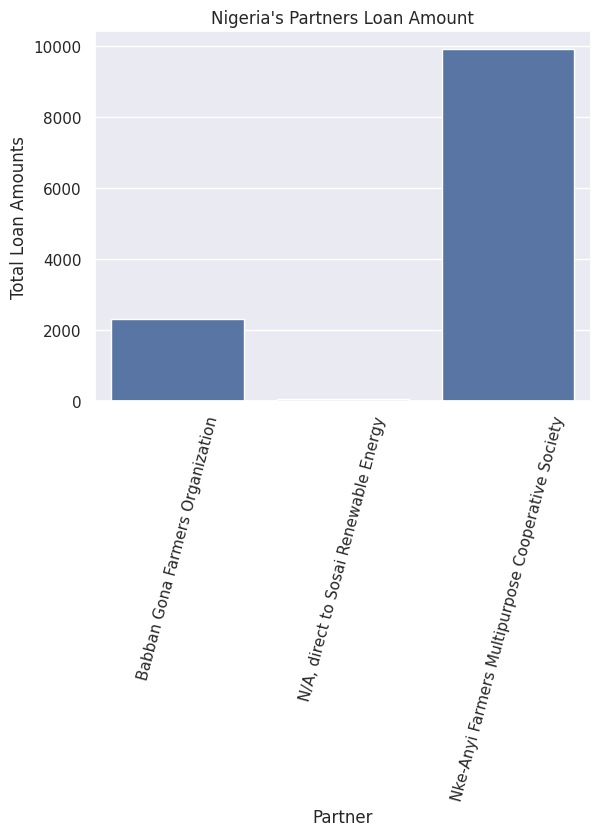

In [96]:
sns.barplot(x=nigeria_partners['partners'],y=nigeria_partners['loan_amount'])
plt.title("Nigeria's Partners Loan Amount")
plt.xlabel('Partner')
plt.ylabel('Total Loan Amounts')
plt.xticks(rotation = 75)
plt.show()

#The partner names and their total funded amount.

In [97]:
nigeria_partners_funded = nigeria.groupby('partners')['funded_amount'].sum().reset_index()
nigeria_partners_funded

,partners,funded_amount
0,Babban Gona Farmers Organization,2300.0
1,"N/A, direct to Sosai Renewable Energy",50.0
2,Nke-Anyi Farmers Multipurpose Cooperative Society,9925.0


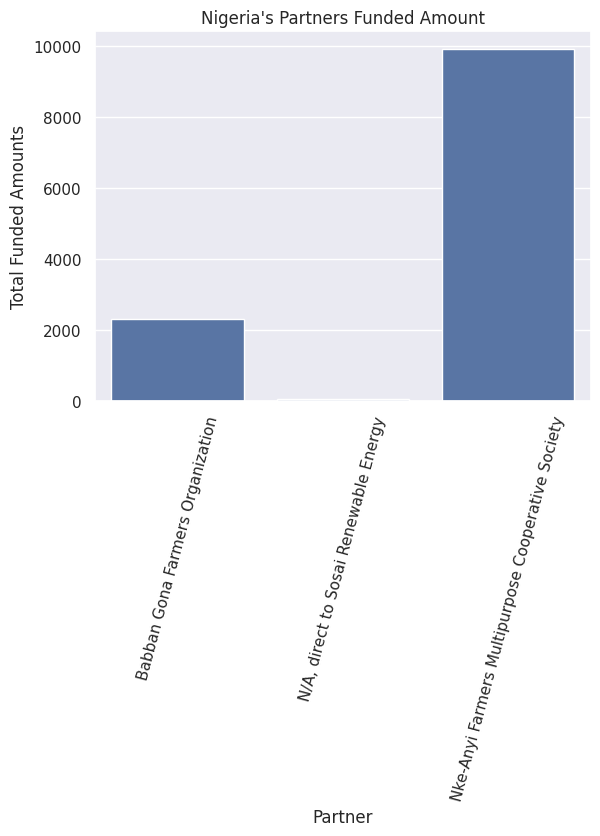

In [98]:
sns.barplot(x=nigeria_partners_funded['partners'],y=nigeria_partners_funded['funded_amount'])
plt.title("Nigeria's Partners Funded Amount")
plt.xlabel('Partner')
plt.ylabel('Total Funded Amounts')
plt.xticks(rotation = 75)
plt.show()

#The partner names and their total number of loans.

In [99]:
nigeria['partners'].value_counts()

,count
partners,
Nke-Anyi Farmers Multipurpose Cooperative Society,17
Babban Gona Farmers Organization,2
"N/A, direct to Sosai Renewable Energy",1


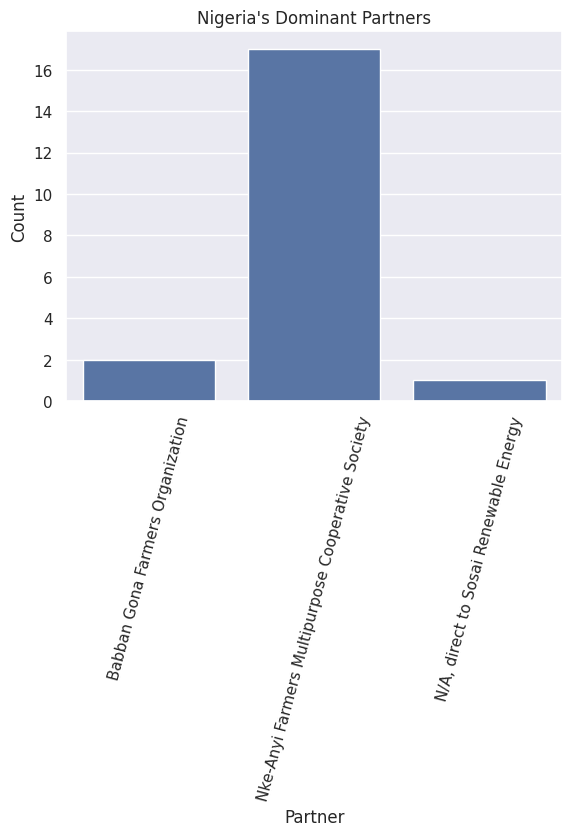

In [100]:
sns.countplot(x = nigeria['partners'])
plt.title("Nigeria's Dominant Partners")
plt.xlabel('Partner')
plt.ylabel('Count')
plt.xticks(rotation = 75)
plt.show()

#Top reasons for giving a loan.

In [101]:
nigeria.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date,main_gender,partners
0,689794,1450.0,1450.0,Agriculture,Agriculture,to help Uche purchase a modern palm oil proces...,NG,Nigeria,Amichi,NGN,...,2014-06-24 07:00:00+00:00,2014-04-04 15:49:54+00:00,11.0,50,"#Biz Durable Asset, #Supporting Family, #Job C...",female,bullet,2014-03-27,female,Babban Gona Farmers Organization
1,689739,850.0,850.0,Agriculture,Agriculture,"A loan of 140,000 Naira will help Chinyere pur...",NG,Nigeria,Nnewi,NGN,...,2014-06-24 07:00:00+00:00,2014-04-04 12:48:18+00:00,6.0,30,n_a,female,bullet,2014-03-27,female,Babban Gona Farmers Organization


In [102]:
nigeria['use'].unique()

array(['to help Uche purchase a modern palm oil processing digester with spindle press and Nutcracker for her palm oil mill',
       'A loan of 140,000 Naira will help Chinyere purchase a plastic storage tanks to store processed palm oil for herself and her clients',
       'to help Ebele complete the total cost of building an underground water storage tank for her palm oil mill',
       ...,
       'to purchase improved farm inputs which will increase his farm yield.',
       'to purchase palm kernel processing equipment',
       'to process palm kernel products'], dtype=object)

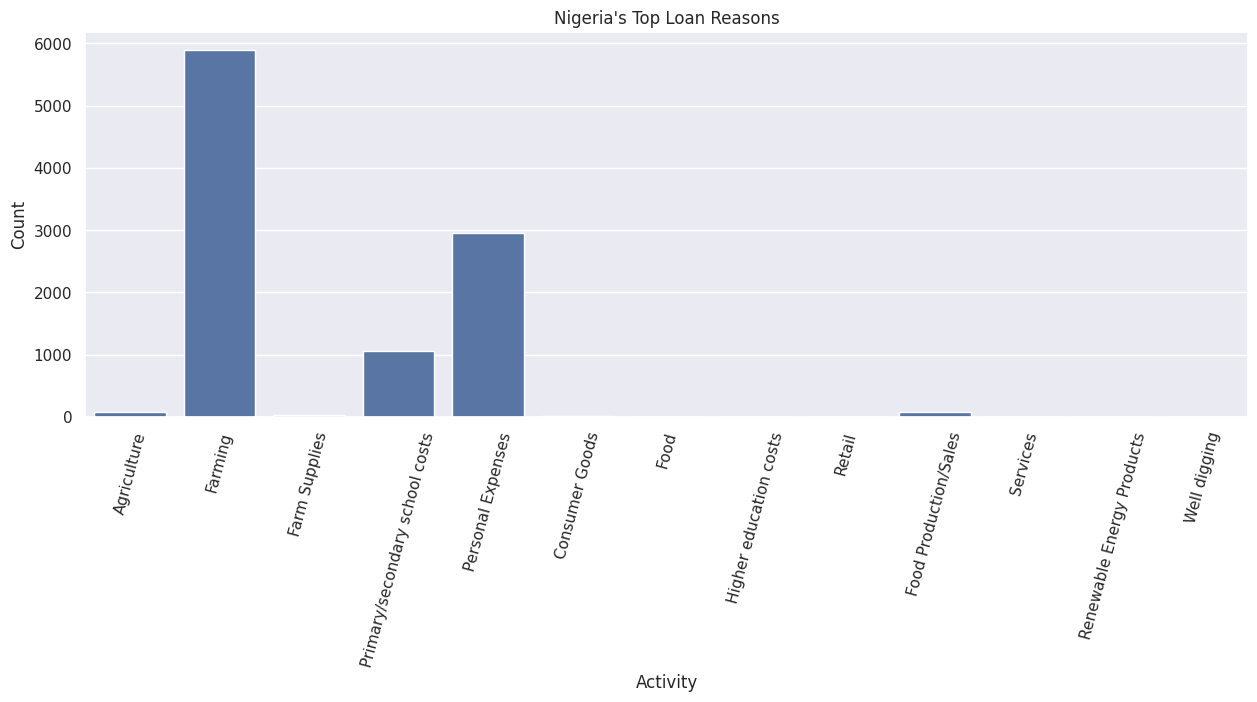

In [103]:
plt.figure(figsize=(15,5))
sns.countplot(x = nigeria['activity'])
plt.title("Nigeria's Top Loan Reasons")
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation = 75)
plt.show()

#The distribution of the loan amount.

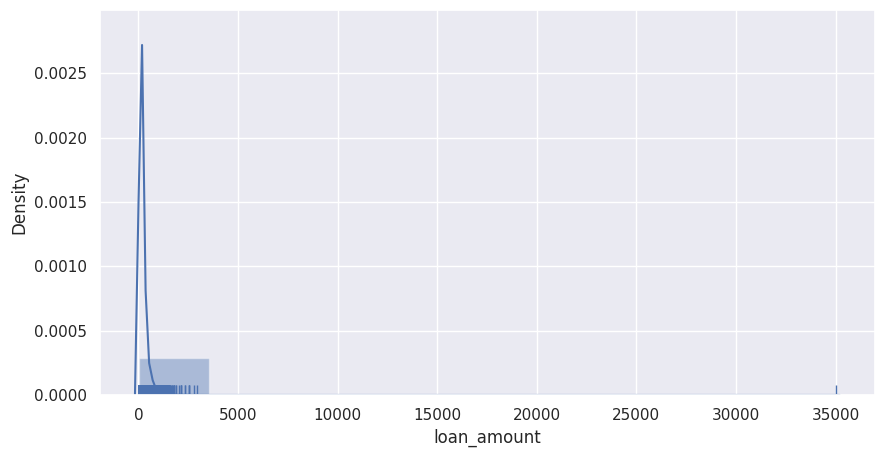

In [104]:
plt.figure(figsize = (10,5))
sns.distplot(nigeria['loan_amount'],bins = 10, rug = True)

plt.show()

#The distribution of the funded amount.

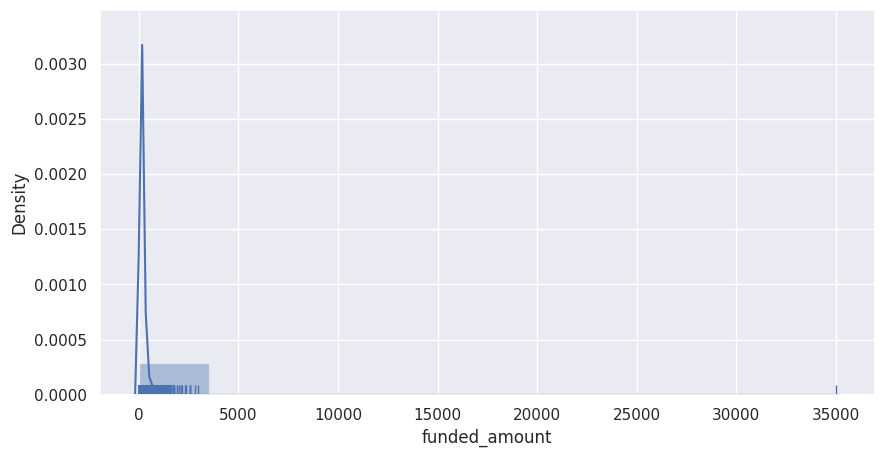

In [105]:
plt.figure(figsize = (10,5))
sns.distplot(nigeria['funded_amount'],rug = True, bins = 10)

plt.show()

#The distribution of the repayment term.

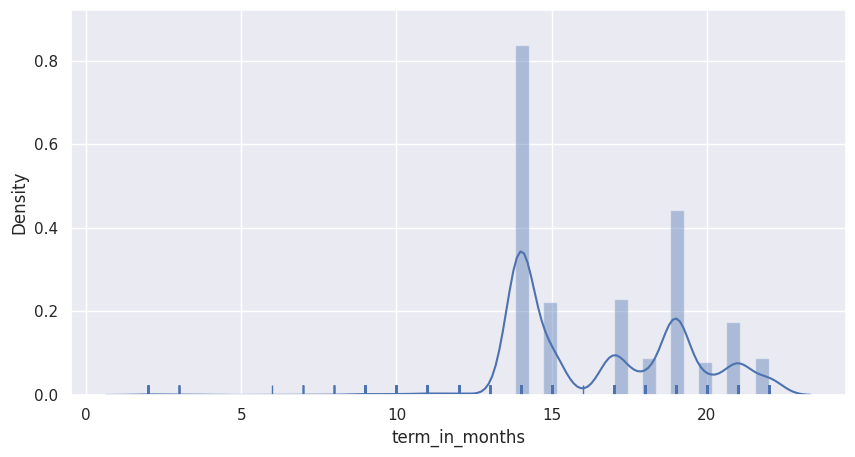

In [106]:
plt.figure(figsize = (10,5))
sns.distplot(nigeria['term_in_months'], rug = True)

plt.show()

#The lender count against the funded amount. Explain the obtained results.

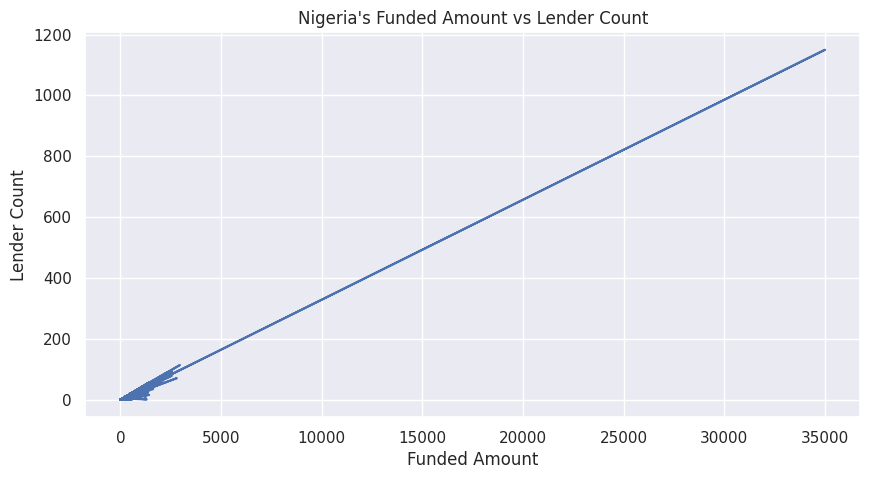

In [108]:
plt.figure(figsize = (10,5))
plt.plot(nigeria['funded_amount'],nigeria['lender_count'])
plt.title("Nigeria's Funded Amount vs Lender Count")
plt.xlabel('Funded Amount')
plt.ylabel('Lender Count')
plt.show()

#The distribution of the funded amount by region.

In [109]:
nigeria_region_funded = nigeria.groupby('region')['funded_amount'].sum().reset_index()
nigeria_region_funded

,region,funded_amount
0,Abobur,6325.0
1,Akaboezem,8700.0
2,Akatta Oru East,1000.0
3,Amichi,2225.0
4,Elele,1475.0
5,Enugu-ukwe,4050.0
6,Kaduna,1751275.0
7,Nnewi,18600.0
8,Nnewichi,10150.0
9,Nnobi,6400.0


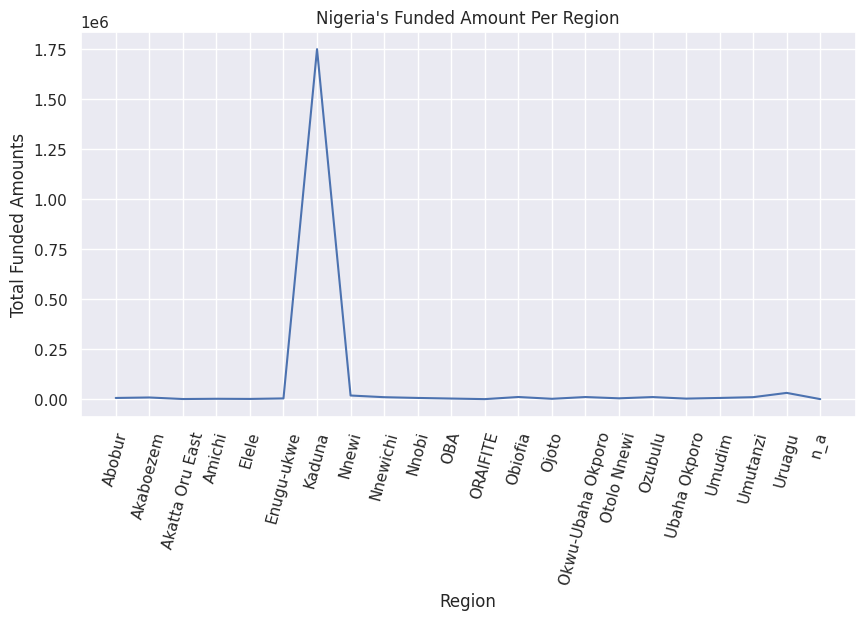

In [111]:
plt.figure(figsize = (10,5))
sns.lineplot(x=nigeria_region_funded['region'],y=nigeria_region_funded['funded_amount'])
plt.title("Nigeria's Funded Amount Per Region")
plt.xlabel('Region')
plt.ylabel('Total Funded Amounts')
plt.xticks(rotation = 75)
plt.show()

#The funded amount with the sector as the hue.

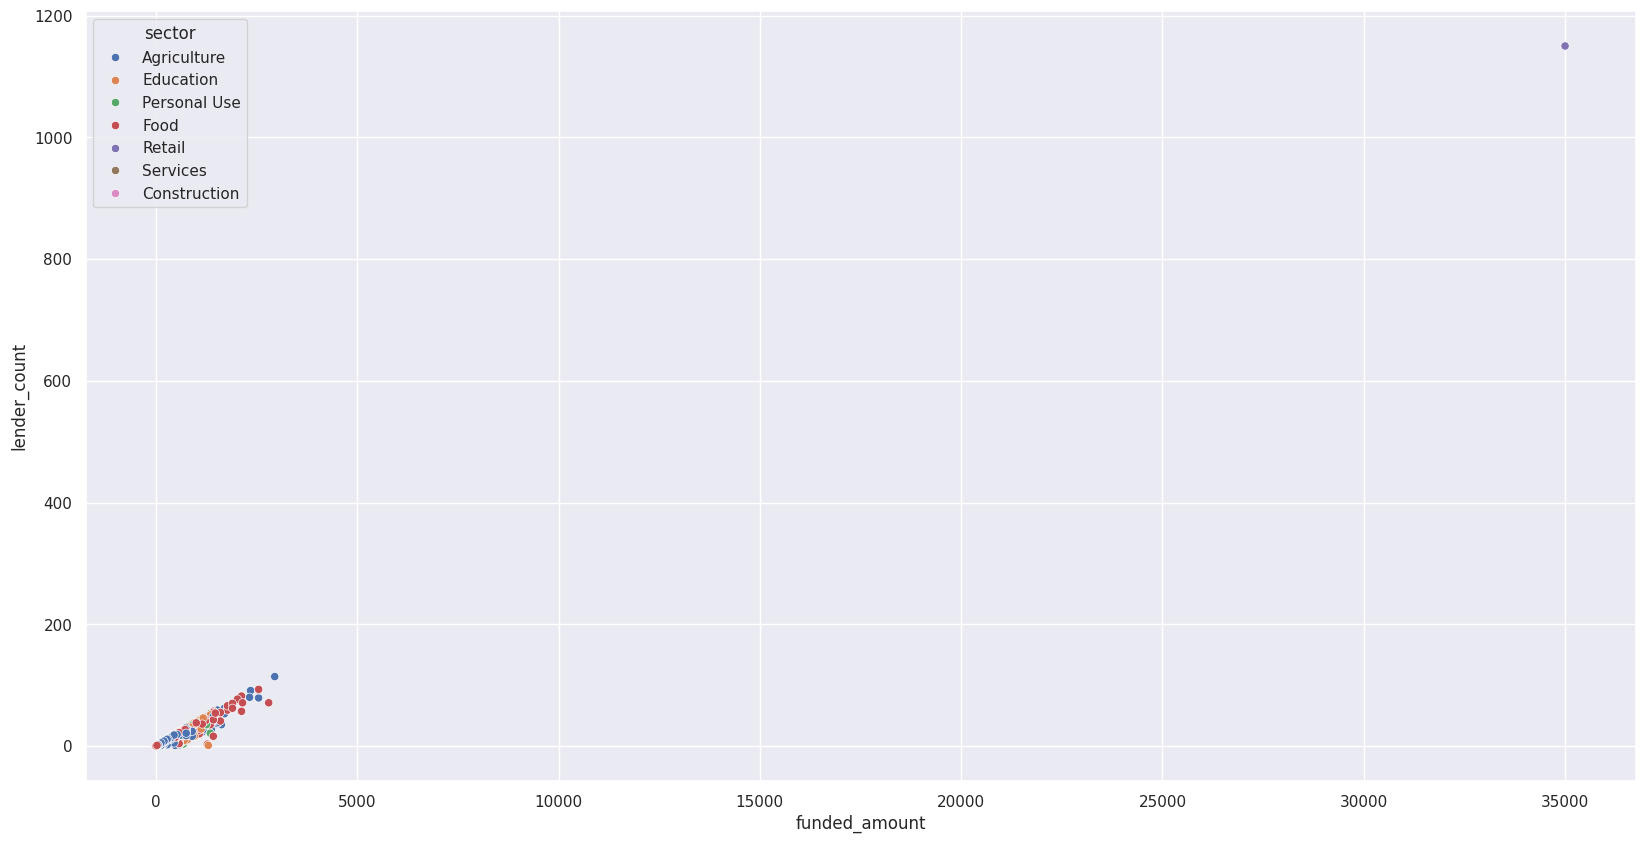

In [112]:
plt.figure(figsize = (20,10))
sns.scatterplot(x = 'funded_amount', y = 'lender_count', hue = 'sector', data = nigeria)

plt.show()

#A boxplot of regions against funded amount.

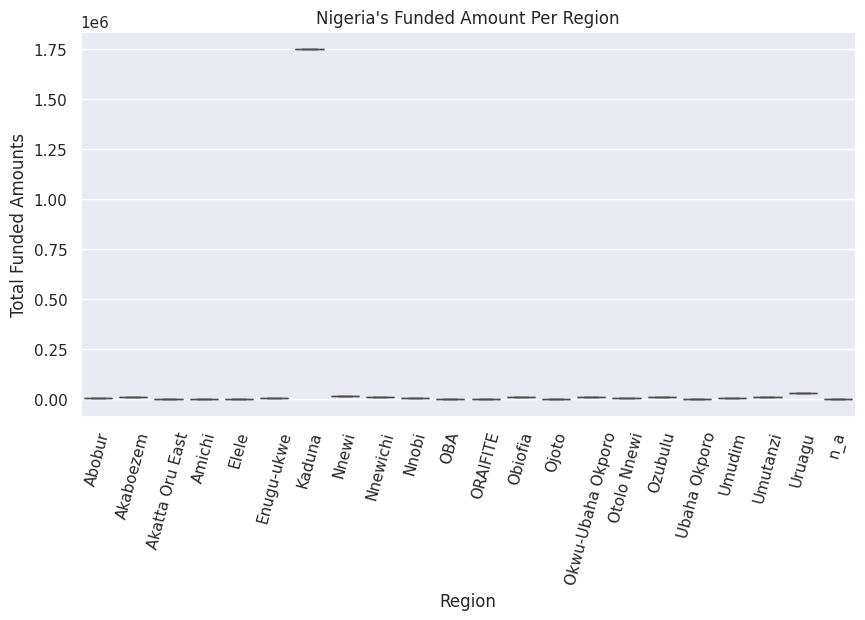

In [116]:
plt.figure(figsize = (10,5))
sns.boxplot(x=nigeria_region_funded['region'],y=nigeria_region_funded['funded_amount'])
plt.title("Nigeria's Funded Amount Per Region")
plt.xlabel('Region')
plt.ylabel('Total Funded Amounts')
plt.xticks(rotation = 75)
plt.show()

#The repayment interval for different regions.

In [117]:
nigeria[['region','repayment_interval']]

,region,repayment_interval
0,Amichi,bullet
1,Nnewi,bullet
2,Elele,bullet
3,Umutanzi,bullet
4,Umutanzi,bullet
...,...,...
10131,Kaduna,bullet
10132,Kaduna,bullet
10133,Kaduna,bullet
10134,Nnobi,bullet


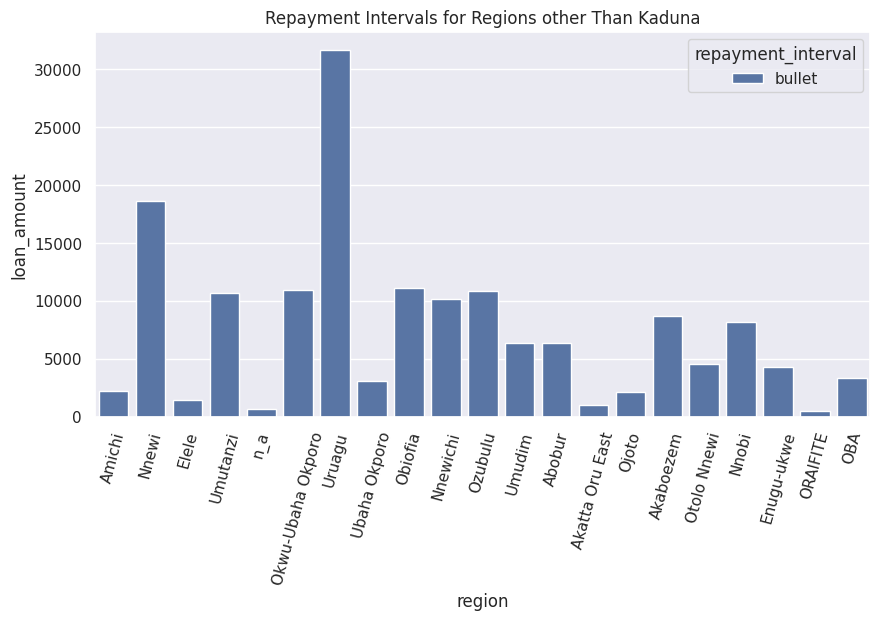

In [118]:
nig_repayment_interval = nigeria_repayment_interval[nigeria_repayment_interval['region']!='Kaduna']
plt.figure(figsize = (10,5))
plt.title("Repayment Intervals for Regions other Than Kaduna")
sns.barplot(x = 'region', y = 'loan_amount', data = nig_repayment_interval, ci = None,
           estimator = np.sum, hue = 'repayment_interval')
plt.xticks(rotation = 75)
plt.show()

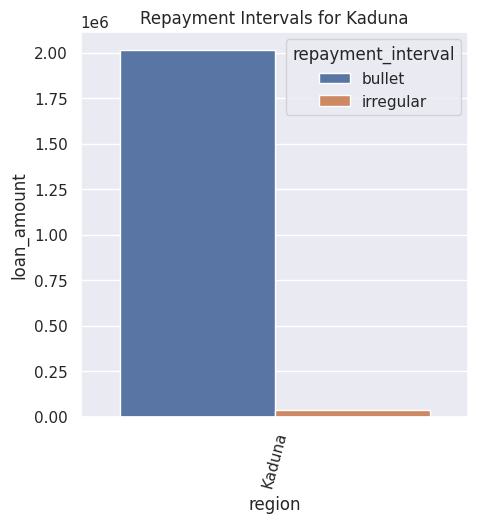

In [119]:
nig_repayment_interval_kaduna = nigeria_repayment_interval[nigeria_repayment_interval['region']=='Kaduna']
plt.figure(figsize = (5,5))
plt.title("Repayment Intervals for Kaduna")
sns.barplot(x = 'region', y = 'loan_amount', data = nig_repayment_interval_kaduna, ci = None,
           estimator = np.sum, hue = 'repayment_interval')
plt.xticks(rotation = 75)
plt.show()

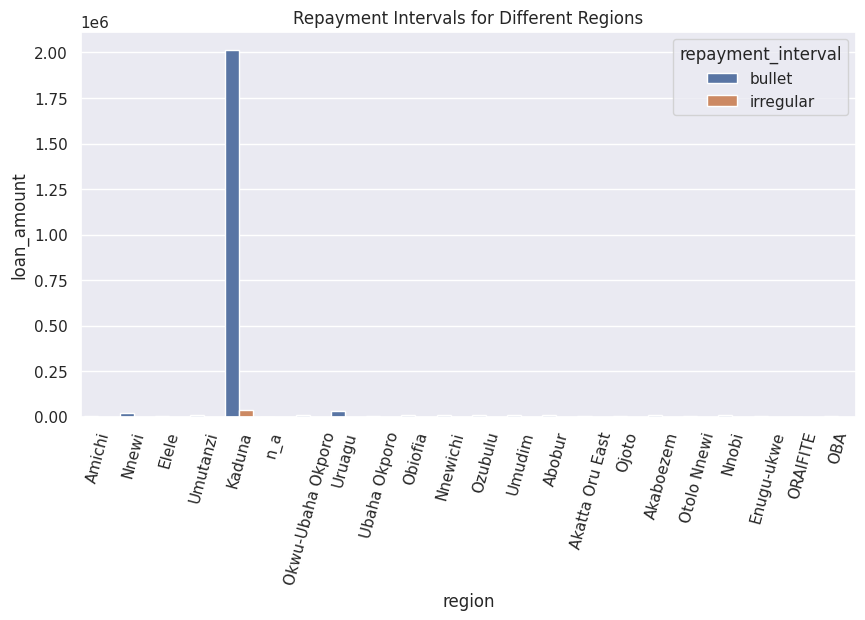

In [120]:
plt.figure(figsize = (10,5))
plt.title("Repayment Intervals for Different Regions")
sns.barplot(x = 'region', y = 'loan_amount', data = nigeria_repayment_interval, ci = None,
           estimator = np.sum, hue = 'repayment_interval')
plt.xticks(rotation = 75)
plt.show()

#Boxplots of the loan amount in sectors

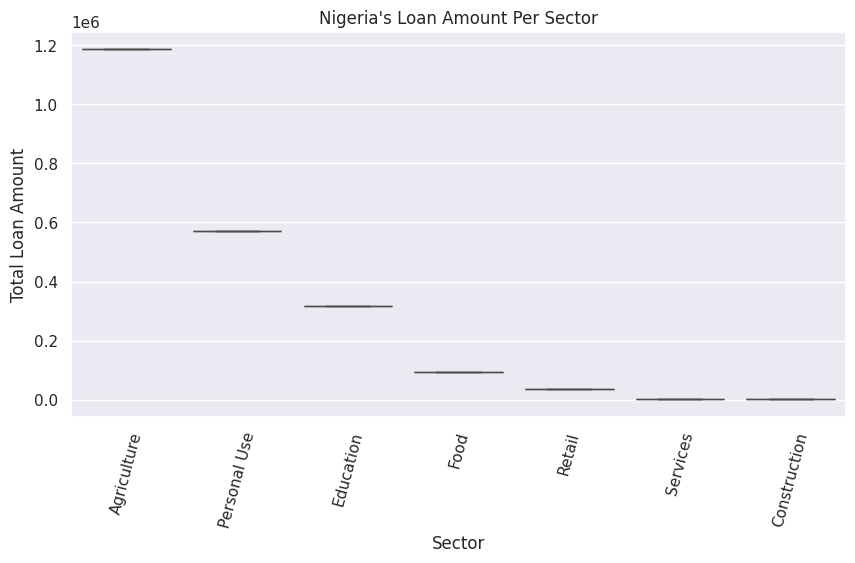

In [122]:
plt.figure(figsize = (10,5))
sns.boxplot(x=nigeria_sector_loans['sector'],y=nigeria_sector_loans['loan_amount_total'])
plt.title("Nigeria's Loan Amount Per Sector")
plt.xlabel('Sector')
plt.ylabel('Total Loan Amount')
plt.xticks(rotation = 75)
plt.show()

#The number of field partners per region. (MPI dataset)

In [123]:
nigeria_2.columns

Index(['Partner ID', 'Field Partner Name', 'sector', 'Loan Theme ID',
       'Loan Theme Type', 'country', 'forkiva', 'region', 'geocode_old', 'ISO',
       'number', 'amount', 'LocationName', 'geocode', 'names', 'geo', 'lat',
       'lon', 'mpi_region', 'mpi_geo', 'rural_pct'],
      dtype='object')

In [124]:
nigeria_2.groupby('region')['Field Partner Name'].value_counts()

region             Field Partner Name                               
Abobur             Nke-Anyi Farmers Multipurpose Cooperative Society    1
Akaboezem          Nke-Anyi Farmers Multipurpose Cooperative Society    1
Akatta Oru East    Nke-Anyi Farmers Multipurpose Cooperative Society    1
Enugu-ukwe         Nke-Anyi Farmers Multipurpose Cooperative Society    1
Kaduna             Babban Gona Farmers Organization                     2
                   N/A, direct to Sosai Renewable Energy                1
Nnewi              Nke-Anyi Farmers Multipurpose Cooperative Society    1
Nnewichi           Nke-Anyi Farmers Multipurpose Cooperative Society    1
Nnobi              Nke-Anyi Farmers Multipurpose Cooperative Society    1
OBA                Nke-Anyi Farmers Multipurpose Cooperative Society    1
ORAIFITE           Nke-Anyi Farmers Multipurpose Cooperative Society    1
Obiofia            Nke-Anyi Farmers Multipurpose Cooperative Society    1
Ojoto              Nke-Anyi Farmers Multipurpose Cooperative Society    1
Okwu-Ubaha Okporo  Nke-Anyi Farmers Multipurpose Cooperative Society    1
Otolo Nnewi        Nke-Anyi Farmers Multipurpose Cooperative Society    1
Ozubulu            Nke-Anyi Farmers Multipurpose Cooperative Society    1
Umudim             Nke-Anyi Farmers Multipurpose Cooperative Society    1
Umutanzi           Nke-Anyi Farmers Multipurpose Cooperative Society    1
Uruagu             Nke-Anyi Farmers Multipurpose Cooperative Society    1
Name: count, dtype: int64

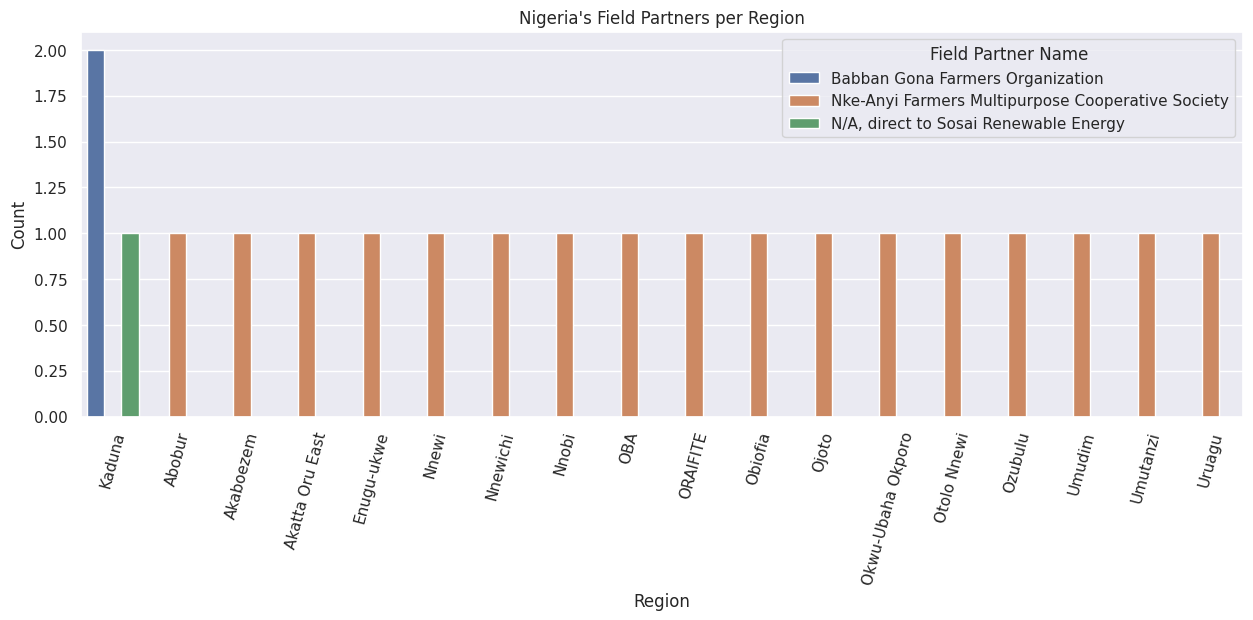

In [125]:
plt.figure(figsize=[15,5])
sns.countplot(x = nigeria_2['region'], hue = nigeria_2['Field Partner Name'])
plt.title("Nigeria's Field Partners per Region")
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation = 75)
plt.show()

#The number of regions.

In [126]:
nigeria['region'].nunique()

22

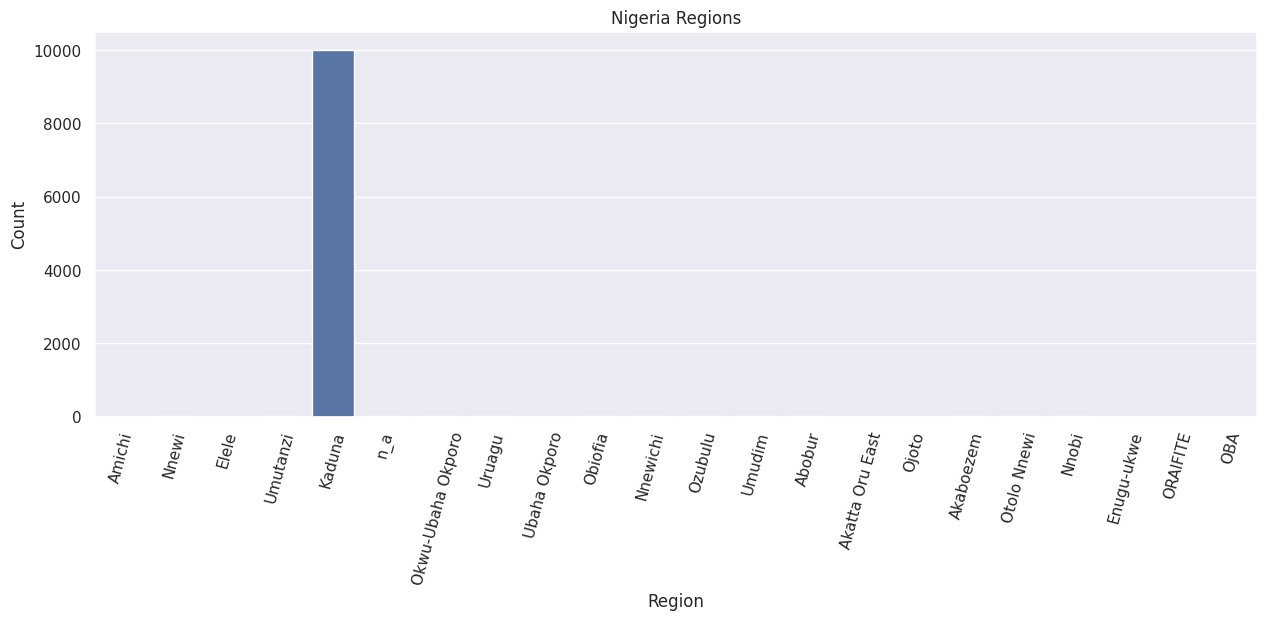

In [127]:
plt.figure(figsize=[15,5])
sns.countplot(x = nigeria['region'])
plt.title("Nigeria Regions")
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation = 75)
plt.show()

#The number of loans per region.

In [129]:
loan_count_region_2 = nigeria['region'].value_counts().reset_index()
loan_count_region_2.columns=['region','frequency']
loan_count_region_2

,region,frequency
0,Kaduna,10000
1,Uruagu,28
2,Nnewi,13
3,Nnewichi,10
4,Ozubulu,9
5,Okwu-Ubaha Okporo,9
6,Nnobi,9
7,Obiofia,8
8,Akaboezem,7
9,Umutanzi,7


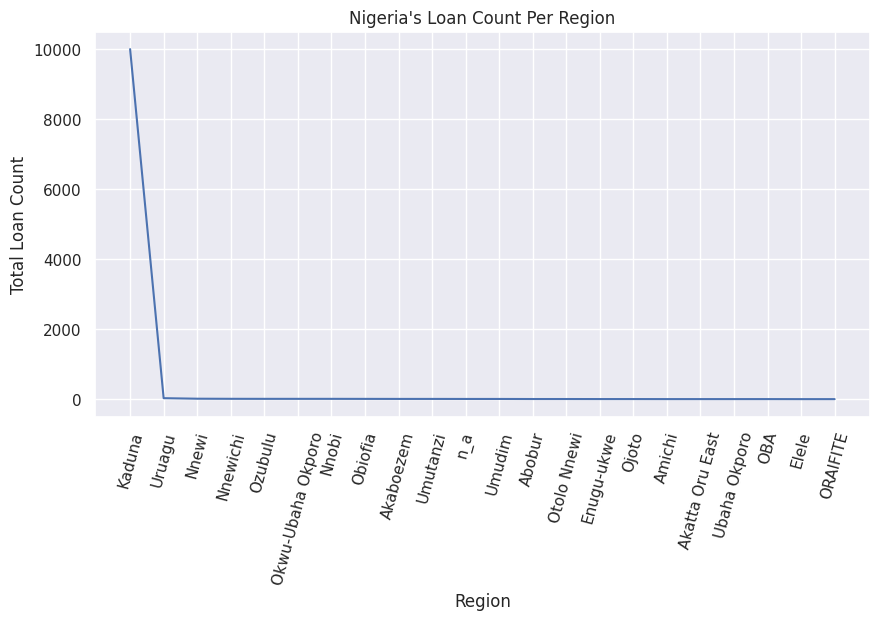

In [131]:
plt.figure(figsize = (10,5))
sns.lineplot(x=loan_count_region_2['region'],y=loan_count_region_2['frequency'])
plt.title("Nigeria's Loan Count Per Region")
plt.xlabel('Region')
plt.ylabel('Total Loan Count')
plt.xticks(rotation = 75)
plt.show()

#The number of loans per sector.¶

In [132]:
nigeria['sector'].value_counts()

,count
sector,
Agriculture,5996
Personal Use,2983
Education,1064
Food,85
Retail,4
Services,3
Construction,1


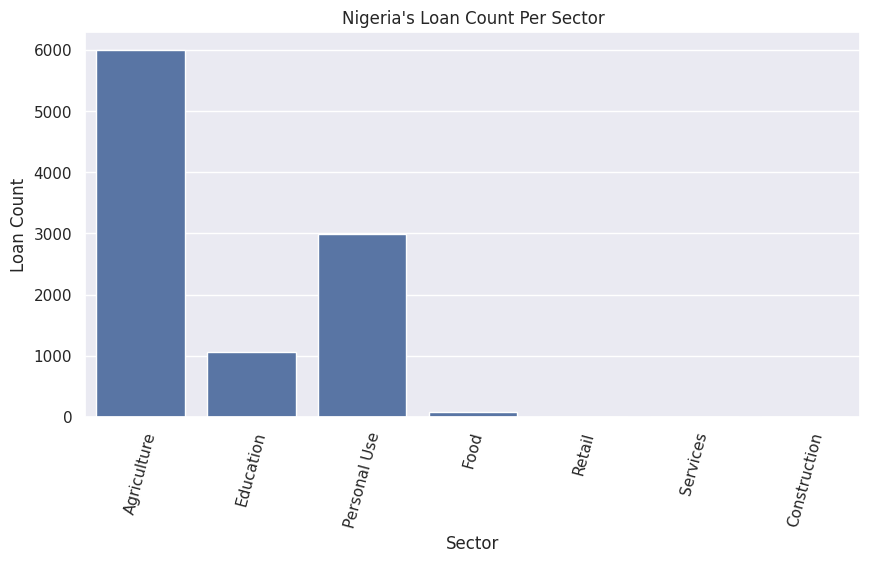

In [133]:
plt.figure(figsize = (10,5))
sns.countplot(x = nigeria['sector'])
plt.title("Nigeria's Loan Count Per Sector")
plt.xlabel('Sector')
plt.ylabel('Loan Count')
plt.xticks(rotation = 75)
plt.show()